In [ ]:
import torch
print(f'PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}')
import numpy
print(f'numpy: {numpy.__version__}')
import laion_clap
print('laion_clap: OK')
from sam_audio import SAMAudio, SAMAudioProcessor
print('SAM-Audio: SUCCESS!')

/teamspace/studios/this_studio/turkish-instrument/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


PyTorch: 2.11.0+cu130, CUDA: True
numpy: 1.26.4


/teamspace/studios/this_studio/turkish-instrument/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/teamspace/studios/this_studio/turkish-instrument/.venv/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.10.0+cu128 with CUDA 1208 (you have 2.11.0+cu130)
    Python  3.10.19 (you have 3.11.13)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 

laion_clap: OK


/teamspace/studios/this_studio/turkish-instrument/.venv/lib/python3.11/site-packages/imagebind/data.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


SAM-Audio: SUCCESS!


In [2]:
import os
from huggingface_hub import login
from dotenv import load_dotenv

load_dotenv()

login(token=os.getenv("HF_TOKEN"))

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [ ]:
import torch
from sam_audio import SAMAudio, SAMAudioProcessor

MODEL_ID = "facebook/sam-audio-base"  # base model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SAMAudio.from_pretrained(MODEL_ID).eval()

# Use fp16 on GPU to cut VRAM roughly in half (3090 supports fp16 well)
model = model.to(device=device, dtype=torch.float16).eval()

processor = SAMAudioProcessor.from_pretrained(MODEL_ID)

print("Device:", device)
print("Sampling rate:", processor.audio_sampling_rate)

Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 23777.23it/s]


/teamspace/studios/this_studio/turkish-instrument/.venv/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/teamspace/studios/this_studio/turkish-instrument/.venv/lib/python3.11/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 59074.70it/s]
/teamspace/studios/

Device: cuda
Sampling rate: 48000


In [5]:
from datasets import load_dataset
from IPython.display import Audio

dataset = load_dataset("audiofolder", data_dir="../data/mixed/")
samples = dataset["train"][8]["audio"].get_all_samples()
Audio(samples.data, rate=samples.sample_rate)

Generating train split: 60 examples [00:00, 1239.09 examples/s]


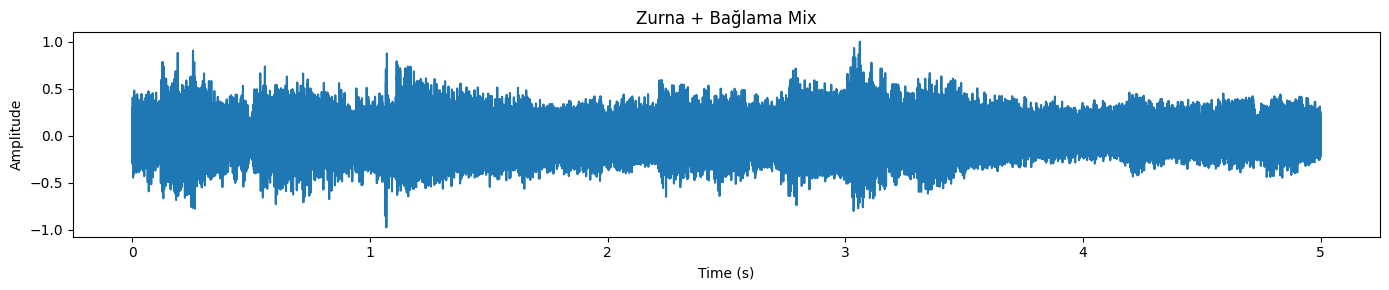

In [ ]:
import matplotlib.pyplot as plt

def plot_waveform(wav, sr, title="Waveform", max_seconds=15):
    """
    wav: Tensor [C, T] or [T]
    sr: sample rate (int)
    """
    if isinstance(wav, torch.Tensor):
        w = wav.detach().cpu()
    else:
        w = torch.tensor(wav)

    if w.ndim == 1:
        w = w.unsqueeze(0)

    # limit duration for readability
    max_samples = int(sr * max_seconds)
    w = w[:, :max_samples]

    t = torch.arange(w.shape[1]) / sr

    plt.figure(figsize=(14, 3))
    for c in range(w.shape[0]):
        plt.plot(t, w[c].numpy(), label=f"ch{c}")
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    if w.shape[0] > 1:
        plt.legend()
    plt.tight_layout()
    plt.show()

plot_waveform(samples.data, samples.sample_rate, title="Zurna + Bağlama Mix")

In [7]:
import torchaudio


wav = torch.tensor(samples.data)

# Ensure [C, T]
if wav.ndim == 1:
    wav = wav.unsqueeze(0)  # [1, T]
elif wav.ndim == 2 and wav.shape[0] > wav.shape[1]:
    wav = wav.transpose(0, 1)  # [T, C] -> [C, T]

wav = wav.float()

orig_sr = int(samples.sample_rate)
target_sr = int(processor.audio_sampling_rate)

if orig_sr != target_sr:
    wav = torchaudio.functional.resample(wav, orig_sr, target_sr)

# Mono
wav = wav.mean(0, keepdim=True)  # [1, T]

# Move to device + match model dtype (FP16 on CUDA)
wav = wav.to(device=device, dtype=next(model.parameters()).dtype)

duration_s = wav.shape[-1] / target_sr
print(f"Resampled duration: {duration_s:.2f}s @ {target_sr} Hz")

Resampled duration: 5.00s @ 48000 Hz


/tmp/ipykernel_46037/1770827051.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  wav = torch.tensor(samples.data)


In [13]:
description = "zurna sound only"
# anchors = [[["+", ]]]

inputs = processor(
    audios=[wav],
    descriptions=[description],
).to(device)

with torch.inference_mode():
    result = model.separate(inputs)

target_np = result.target[0].detach().float().cpu().numpy()
resid_np = result.residual[0].detach().float().cpu().numpy()
Audio(target_np, rate=processor.audio_sampling_rate)

In [14]:
Audio(resid_np, rate=processor.audio_sampling_rate)

In [15]:
samples_2 = dataset["train"][3]["audio"].get_all_samples()
Audio(samples_2.data, rate=samples_2.sample_rate)

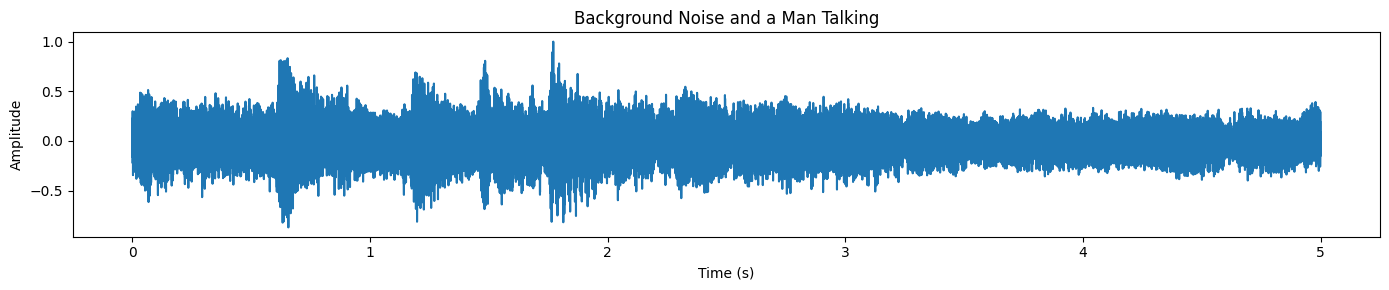

In [16]:
plot_waveform(samples_2.data, samples_2.sample_rate, title="Background Noise and a Man Talking")

In [17]:
# Convert numpy → torch
wav = torch.tensor(samples_2.data)

# Ensure [C, T]
if wav.ndim == 1:
    wav = wav.unsqueeze(0)
elif wav.ndim == 2 and wav.shape[0] > wav.shape[1]:
    wav = wav.transpose(0, 1)

wav = wav.float()

orig_sr = int(samples.sample_rate)
target_sr = int(processor.audio_sampling_rate)

# Resample if needed
if orig_sr != target_sr:
    wav = torchaudio.functional.resample(wav, orig_sr, target_sr)

# Mono
wav = wav.mean(0, keepdim=True)

# Move to GPU + FP16
wav = wav.to(device=device, dtype=next(model.parameters()).dtype)

duration_s = wav.shape[-1] / target_sr
print(f"Duration: {duration_s:.2f}s @ {target_sr} Hz")


Duration: 5.00s @ 48000 Hz


/tmp/ipykernel_46037/196246690.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  wav = torch.tensor(samples_2.data)


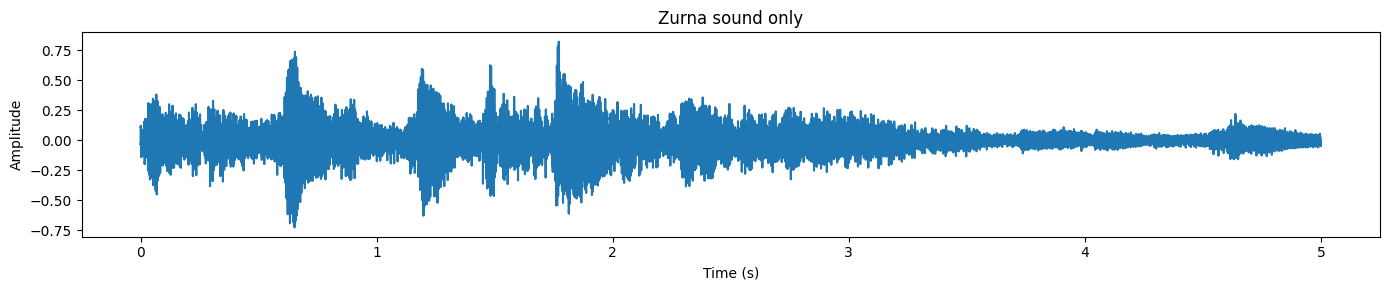

In [24]:
description = "a trumpet-like musical instrument sound only"

inputs = processor(
    audios=[wav],
    descriptions=[description],
).to(device)

with torch.inference_mode():
    result = model.separate(inputs)
target_np = result.target[0].detach().float().cpu().numpy()

plot_waveform(target_np, processor.audio_sampling_rate, title="Zurna sound only")

In [25]:
Audio(target_np, rate=processor.audio_sampling_rate)